In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import os, json, math, random, pickle, shutil, socket, inspect, argparse, subprocess, warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

import librosa
from tqdm import tqdm
from IPython.display import Audio

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import datasets, transforms

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger

import umap
from sklearn.manifold import TSNE

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.mixture import GaussianMixture

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

from sklearn.model_selection import StratifiedKFold, GroupKFold, train_test_split

from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
    silhouette_score, silhouette_samples, davies_bouldin_score
)

import train
import commons
import models
import utils
import lightning_wrapper

from cough_datasets import (
    CoughDatasets,
    CoughDatasetsCollate,
    CoughDiseaseBinaryBatchSampler
)

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_3273396/2465909003.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [2]:
def _aprior(delta_hat: np.ndarray) -> np.ndarray:
    """ComBat EM prior: shape parameter for inverse gamma."""
    m = delta_hat.mean(axis=1)
    s2 = delta_hat.var(axis=1) + 1e-8
    return (2 * s2 + m**2) / s2


def _bprior(delta_hat: np.ndarray) -> np.ndarray:
    """ComBat EM prior: scale parameter for inverse gamma."""
    m = delta_hat.mean(axis=1)
    s2 = delta_hat.var(axis=1) + 1e-8
    return (m * s2 + m**3) / s2

def combat_harmonize(
    embeddings: np.ndarray,
    db_labels: np.ndarray,
    covariates: np.ndarray = None,
    n_iter: int = 30,
    conv_threshold: float = 1e-4,
) -> np.ndarray:
    """
    Empirical Bayes ComBat harmonization.
    
    Removes additive (gamma) and multiplicative (delta) batch effects
    while preserving biological signal via covariate design matrix.
    
    Parameters
    ----------
    embeddings   : (N, D) float array
    db_labels    : (N,) array of database IDs
    covariates   : (N, C) optional biological covariates to preserve
                   (e.g. disease_status encoded as 0/1)
    n_iter       : EM iterations for Bayesian shrinkage
    conv_threshold: convergence tolerance
    
    Returns
    -------
    harmonized   : (N, D) float array
    """
    N, D = embeddings.shape
    batches = np.unique(db_labels)
    n_batches = len(batches)
    
    # 1. Build design matrix
    # Intercept + covariates (biological signal to preserve)
    if covariates is not None:
        if covariates.ndim == 1:
            covariates = covariates.reshape(-1, 1)
        design = np.hstack([np.ones((N, 1)), covariates])
    else:
        design = np.ones((N, 1))
    
    # 2. Standardize overall
    grand_mean = embeddings.mean(axis=0)
    var_pooled = embeddings.var(axis=0) + 1e-8
    
    # 3. Regress out covariates to get residuals
    # Solve: embeddings = design @ B + residuals
    B, _, _, _ = np.linalg.lstsq(design, embeddings, rcond=None)
    residuals = embeddings - design @ B
    
    # 4. Standardize residuals
    stand_mean = (grand_mean / np.sqrt(var_pooled))
    s_data = (embeddings - grand_mean) / np.sqrt(var_pooled)
    
    # 5. Estimate batch effects (gamma_hat = additive, delta_hat = multiplicative)
    gamma_hat = np.zeros((n_batches, D))
    delta_hat = np.zeros((n_batches, D))
    
    batch_idx = {}
    for i, b in enumerate(batches):
        mask = db_labels == b
        batch_idx[i] = mask
        batch_data = s_data[mask]
        gamma_hat[i] = batch_data.mean(axis=0)
        delta_hat[i] = batch_data.var(axis=0) + 1e-8
    
    # 6. Empirical Bayes priors
    gamma_bar = gamma_hat.mean(axis=0)
    t2 = gamma_hat.var(axis=0) + 1e-8
    
    a_prior = _aprior(delta_hat)
    b_prior = _bprior(delta_hat)
    
    # 7. EM iteration for posterior estimates
    gamma_star = gamma_hat.copy()
    delta_star = delta_hat.copy()
    
    for _ in range(n_iter):
        gamma_star_new = np.zeros_like(gamma_hat)
        delta_star_new = np.zeros_like(delta_hat)
        
        for i, b in enumerate(batches):
            mask = batch_idx[i]
            n_i = mask.sum()
            batch_data = s_data[mask]
            
            # Posterior gamma (additive)
            gamma_star_new[i] = (
                (t2 * n_i * batch_data.mean(axis=0) + delta_star[i] * gamma_bar)
                / (t2 * n_i + delta_star[i])
            )
            
            # Posterior delta (multiplicative) via inverse gamma
            sum_sq = ((batch_data - gamma_star_new[i]) ** 2).sum(axis=0)
            delta_star_new[i] = (b_prior[i] + 0.5 * sum_sq) / (a_prior[i] + n_i / 2.0 - 1)
            delta_star_new[i] = np.maximum(delta_star_new[i], 1e-8)
        
        # Check convergence
        g_change = np.abs(gamma_star_new - gamma_star).max()
        d_change = np.abs(delta_star_new - delta_star).max()
        gamma_star = gamma_star_new
        delta_star = delta_star_new
        
        if g_change < conv_threshold and d_change < conv_threshold:
            break
    
    # 8. Apply correction
    harmonized = s_data.copy()
    for i, b in enumerate(batches):
        mask = batch_idx[i]
        harmonized[mask] = (
            (s_data[mask] - gamma_star[i]) / np.sqrt(delta_star[i])
        )
    
    # 9. Rescale back to original space
    harmonized = harmonized * np.sqrt(var_pooled) + grand_mean
    
    # Re-apply biological covariates
    harmonized = harmonized + design @ B - grand_mean
    
    return harmonized

def compute_mmd(X: np.ndarray, Y: np.ndarray, gamma: float = None) -> float:
    """
    Unbiased MMD² with RBF kernel.
    Lower = more similar distributions (better harmonization).
    """
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    
    def rbf_kernel(A, B):
        dists = np.sum((A[:, None] - B[None, :]) ** 2, axis=2)
        return np.exp(-gamma * dists)
    
    Kxx = rbf_kernel(X, X)
    Kyy = rbf_kernel(Y, Y)
    Kxy = rbf_kernel(X, Y)
    
    n, m = len(X), len(Y)
    mmd2 = (
        (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
        + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
        - 2 * Kxy.mean()
    )
    return float(mmd2)

def pairwise_mmd_matrix(embeddings: np.ndarray, db_labels: np.ndarray) -> pd.DataFrame:
    """Compute pairwise MMD between all database pairs."""
    batches = np.unique(db_labels)
    n = len(batches)
    matrix = np.zeros((n, n))
    
    for i, b1 in enumerate(batches):
        for j, b2 in enumerate(batches):
            if i != j:
                X = embeddings[db_labels == b1]
                Y = embeddings[db_labels == b2]
                # Subsample for speed if large
                if len(X) > 200: X = X[np.random.choice(len(X), 200, replace=False)]
                if len(Y) > 200: Y = Y[np.random.choice(len(Y), 200, replace=False)]
                matrix[i, j] = compute_mmd(X, Y)
    
    return pd.DataFrame(matrix, index=batches, columns=batches)

def get_classifiers() -> dict:
    """
    Return a dict of classifiers to compare.
    All wrapped in a Pipeline with StandardScaler + PCA for fair comparison.
    PCA(50) reduces 768-dim embeddings to a stable space for all classifiers.
    """
    pca_step = ("pca", PCA(n_components=50, random_state=42))
    scale_step = ("scaler", StandardScaler())

    return {
        "Logistic Regression": Pipeline([
            scale_step, pca_step,
            ("clf", LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
        ]),
        "SVM (RBF)": Pipeline([
            scale_step, pca_step,
            ("clf", SVC(kernel="rbf", probability=True, C=1.0, random_state=42)),
        ])
    }

def run_embedding_classification(
    df,
    train_db,
    test_dbs=None,
    embed_col="embed",
    label_col="disease_status",
    participant_col="participant",
    db_col="db",
    n_splits=5,
    classifiers=None
):
    """
    Flexible evaluation pipeline for embedding-based classification.

    Parameters
    ----------
    df : DataFrame
        Combined dataframe containing embeddings and metadata.
    train_db : int or list
        DB id(s) used for training + cross-validation.
    test_dbs : list or None
        DB ids used as external evaluation sets.
    embed_col : str
        Column containing embeddings.
    label_col : str
        Label column.
    participant_col : str
        Column used for GroupKFold grouping.
    db_col : str
        Database identifier column.
    n_splits : int
        Number of CV folds.
    classifiers : dict
        Dict of sklearn classifiers.

    Returns
    -------
    results : dict
        Mean and std metrics across folds for each classifier.
    """

    if classifiers is None:
        classifiers = get_classifiers()

    if not isinstance(train_db, list):
        train_db = [train_db]

    if test_dbs is None:
        test_dbs = []

    df_train = df[df[db_col].isin(train_db)].copy()

    X = np.vstack(df_train[embed_col].values).astype(np.float32)
    y = df_train[label_col].astype(int).values
    groups = df_train[participant_col].values

    external_sets = {}
    for db in test_dbs:
        df_ext = df[df[db_col] == db]
        X_ext = np.vstack(df_ext[embed_col].values).astype(np.float32)
        y_ext = df_ext[label_col].astype(int).values
        external_sets[db] = (X_ext, y_ext)

    cv = GroupKFold(n_splits=n_splits)
    splits = list(cv.split(X, y, groups=groups))

    model_results = {}
    for clf_name, clf in tqdm(classifiers.items(), desc="Training classifiers"):
        fold_aurocs = []
        fold_aurocs_ext = {db: [] for db in test_dbs}

        for train_idx, test_idx in splits:
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            clf.fit(X_train, y_train)

            y_score = clf.predict_proba(X_test)[:, 1]
            fold_aurocs.append(roc_auc_score(y_test, y_score))

            for db in test_dbs:
                X_ext, y_ext = external_sets[db]
                y_score_ext = clf.predict_proba(X_ext)[:, 1]
                fold_aurocs_ext[db].append(roc_auc_score(y_ext, y_score_ext))

        model_results[clf_name] = {
            "auroc": np.mean(fold_aurocs),
            **{f"auroc_db{db}": np.mean(vals) for db, vals in fold_aurocs_ext.items()}
        }

    # -------- aggregate across models --------

    all_aurocs = [v["auroc"] for v in model_results.values()]

    summary = {
        "mean_auroc_all_models": np.mean(all_aurocs),
        "std_auroc_all_models": np.std(all_aurocs)
    }

    for db in test_dbs:
        vals = [v[f"auroc_db{db}"] for v in model_results.values()]
        summary[f"mean_auroc_db{db}_all_models"] = np.mean(vals)
        summary[f"std_auroc_db{db}_all_models"] = np.std(vals)

    return summary, model_results

def _sigmoid_normalize(scores: np.ndarray) -> np.ndarray:
    """Center and sigmoid-normalize scores to [0, 1]."""
    centered = (scores - scores.mean()) / (scores.std() + 1e-8)
    return 1.0 / (1.0 + np.exp(-centered))

def _minmax_normalize(scores: np.ndarray) -> np.ndarray:
    lo, hi = scores.min(), scores.max()
    return (scores - lo) / (hi - lo + 1e-8)

def best_gmm(data, max_k=6, random_state=42):
    best_bic, best_k = np.inf, 1
    max_k = min(max_k, len(data) // 20)  # need enough samples per component
    max_k = max(max_k, 1)
    for k in range(1, max_k + 1):
        try:
            g = GaussianMixture(n_components=k, covariance_type="diag", random_state=random_state, n_init=3)
            g.fit(data)
            bic = g.bic(data)
            if bic < best_bic:
                best_bic, best_k = bic, k
        except Exception:
            break
    gmm = GaussianMixture(n_components=best_k, covariance_type="diag",
                            random_state=random_state, n_init=5)
    gmm.fit(data)
    print(f"    GMM components selected (BIC): {best_k}")
    return gmm

def find_optimal_k(
    embeddings: np.ndarray,
    k_range: range = None,
    method: str = "silhouette",
    random_state: int = 42,
) -> tuple[int, pd.DataFrame]:
    """
    Find optimal number of clusters via silhouette + elbow analysis.
    
    Returns
    -------
    best_k     : recommended number of clusters
    metrics_df : per-k metrics table
    """
    if k_range is None:
        k_range = range(2, min(8, len(embeddings) // 10 + 1))
    
    pca = PCA(n_components=min(30, embeddings.shape[1]), random_state=random_state)
    emb_pca = pca.fit_transform(embeddings)
    
    records = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=random_state)
        labels = km.fit_predict(emb_pca)
        
        sil = silhouette_score(emb_pca, labels)
        inertia = km.inertia_
        db = davies_bouldin_score(emb_pca, labels)
        records.append({"k": k, "silhouette": sil, "inertia": inertia, "davies_bouldin": db})
    
    df = pd.DataFrame(records)
    
    # Best k = highest silhouette (or use elbow)
    best_k = int(df.loc[df["silhouette"].idxmax(), "k"])
    
    return best_k, df

def cluster_within_class(
    embeddings: np.ndarray,
    class_labels: np.ndarray,
    target_class,
    n_clusters: int = None,
    method: str = "kmeans",
    random_state: int = 42,
) -> tuple[np.ndarray, KMeans, pd.DataFrame]:
    """
    Cluster samples within a specific class (e.g., TB only).
    
    Returns
    -------
    cluster_labels : (N_class,) cluster assignments
    model          : fitted clustering model
    k_metrics      : cluster quality metrics
    """
    mask = class_labels == target_class
    subset = embeddings[mask]
    
    pca = PCA(n_components=min(30, subset.shape[1]), random_state=random_state)
    subset_pca = pca.fit_transform(subset)
    
    if n_clusters is None:
        print(f"    Auto-selecting k for class '{target_class}'...")
        n_clusters, k_metrics = find_optimal_k(subset, random_state=random_state)
        print(f"    → Optimal k = {n_clusters}")
    else:
        k_metrics = pd.DataFrame()
    
    if method == "kmeans":
        model = KMeans(n_clusters=n_clusters, n_init=20, random_state=random_state)
        cluster_labels = model.fit_predict(subset_pca)
    elif method == "gmm":
        model = GaussianMixture(n_components=n_clusters, random_state=random_state,
                                covariance_type="full", n_init=5)
        cluster_labels = model.fit_predict(subset_pca)
    
    return cluster_labels, model, k_metrics, pca

In [3]:
# from s3prl.upstream.mockingjay.builder import PretrainedTransformer
# from s3prl.upstream.mockingjay.model import TransformerSpecPredictionHead
# import s3prl.optimizers
# import sys
# original_optimizer = sys.modules.get("optimizers")
# sys.modules["optimizers"] = s3prl.optimizers

# class TERA_TryDownstream(nn.Module):
#     def __init__(self, input_size, **kwargs):
#         super(TERA_TryDownstream, self).__init__()

#         options = {
#             "load_pretrain": "True",
#             "no_grad": "True",
#             "dropout": "default",
#             "spec_aug": "False",
#             "spec_aug_prev": "False",
#             "output_hidden_states": "True",
#             "permute_input": "False",
#         }
#         options["ckpt_file"] = "/run/media/fourier/Data1/Pras/Thesis_Nexus/s3prl/s3prl/result/pretrain/tera_cough_ssldata_lowlr/states-990000.ckpt"
#         options["select_layer"] = -1
        
#         pretrained_dict = torch.load(options["ckpt_file"], weights_only=False)
#         transformer_state = pretrained_dict['Transformer']
#         spechead_state = pretrained_dict['SpecHead']

#         self.tera_model = PretrainedTransformer(options, inp_dim=-1)
#         self.tera_model.model.load_state_dict(transformer_state, strict=True)
#         self.tera_model.eval()

#         self.spechead_model = TransformerSpecPredictionHead(self.tera_model.model_config, self.tera_model.spec_dim)
#         self.spechead_model.load_state_dict(spechead_state, strict=True)
#         self.spechead_model.eval()

#     def forward(self, x, attention_mask=None, grl_lambda=0.0):
#         x = x.squeeze(1)
#         with torch.no_grad():
#             x = self.tera_model(x)[0] # Index 0 = Last Hidden, Index 1 All Transformwer
#             x = torch.nan_to_num(x, nan=0.0)
#             reconstructed_mel, _ = self.spechead_model(x)
#             reconstructed_mel = reconstructed_mel.transpose(1, 2)

#         mean = x.mean(dim=1)
#         std = x.std(dim=1)
#         feature_embedding = torch.cat([mean, std], dim=1)
#         return {
#             "embeddings": feature_embedding,
#             "reconstructed_mel": reconstructed_mel,
#         }
    
# model = TERA_TryDownstream(1)
# model.cuda()
# model.eval()

# del sys.modules["optimizers"]

class Qwen3_Extractor(nn.Module):
    def __init__(self, dummy, **kwargs):
        super(Qwen3_Extractor, self).__init__()

        from transformers import Qwen3OmniMoeThinkerForConditionalGeneration
        temp_model = Qwen3OmniMoeThinkerForConditionalGeneration.from_pretrained(
            "/run/media/fourier/Data1/Pras/pretrain_models/Qwen3-Omni-30B-A3B-Thinking",
            torch_dtype="auto",
            device_map="cpu"
        )
        self.audio_tower = temp_model.audio_tower
        self.audio_tower.cuda()
        del temp_model
        import gc
        import torch
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        self.audiotower_hidden_dim = self.audio_tower.config.output_dim

    def after_cnn_len(self, L):
        L = (L - 1) // 2 + 1
        L = (L - 1) // 2 + 1
        L = (L - 1) // 2 + 1
        return L

    def forward(self, input_features, attention_mask=None, **kwargs):
        input_features = input_features.to(torch.bfloat16)
        feature_attention_mask = attention_mask.long()
        if feature_attention_mask is not None:
            audio_feature_lengths = torch.sum(feature_attention_mask, dim=1)
            input_features = input_features.permute(
                0, 2, 1)[feature_attention_mask.bool()].permute(1, 0)
        else:
            audio_feature_lengths = None

        feature_lens = audio_feature_lengths if audio_feature_lengths is not None else feature_attention_mask.sum(-1)
        audio_outputs = self.audio_tower(
            input_features,
            feature_lens=feature_lens,
        )
        audio_features = audio_outputs.last_hidden_state
        post_lens = torch.tensor(
            [self.after_cnn_len(l.item()) for l in feature_lens],
            device=feature_lens.device
        )

        total = audio_features.size(0)
        delta = total - post_lens.sum()
        if delta != 0:
            post_lens[-1] += delta

        audio_features = audio_features.split(post_lens.tolist(), dim=0)
        audio_features = pad_sequence(audio_features, batch_first=True) # for Attentive Pooling
        audio_features = audio_features.to(torch.float32)

        mean = audio_features.mean(dim=1)
        std = audio_features.std(dim=1)

        embeddings = torch.cat([mean, std], dim=1)
        return {
            "embeddings": embeddings,
        }

model = Qwen3_Extractor(1)
model.cuda()
model.eval()

parser = train.parse_args()
args = parser.parse_args(["--init", "--model_name", "dev", "--pooling_model",
                          "qwen", "--config_path", "configs/general.json"]) # qwen

model_dir = os.path.join("./logs", args.model_name)
os.makedirs(model_dir, exist_ok=True)
port = None

config_path = args.config_path if args.init else os.path.join(model_dir, "config.json")
hps = train.load_config(config_path, model_dir, args)

df_train, _ = train.load_data(hps)
collate_fn = train.get_collate_fn(hps)
target_labels = df_train[hps.data.target_column]

_, coda_loader = train.prepare_fold_data(
    df_train, df_train, hps, collate_fn,
    use_precomputed=args.use_precomputed,
    precomputed_dir=args.precomputed_dir
)

df_cirdz = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata_cirdz.csv.train')
df_cirdz = df_cirdz.reset_index(drop=True)
df_cirdz = df_cirdz[hps.data.column_order]

_, cirdz_loader = train.prepare_fold_data(
    df_cirdz, df_cirdz, hps, collate_fn,
    use_precomputed=args.use_precomputed,
    precomputed_dir=args.precomputed_dir
)

`torch_dtype` is deprecated! Use `dtype` instead!
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'interleaved', 'mrope_interleaved', 'mrope_section'}


Loading checkpoint shards:   0%|          | 0/16 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [4]:
train_embeds = []
train_wavs = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(coda_loader), total=len(coda_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _, tabular_ids, _]  = batch
        audio = audio.cuda()
        out_model = model(audio, attention_mask=attention_masks)
        embed = out_model['embeddings']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_wavs.extend(wavs_names)
        train_embeds.append(embed.cpu())

train_wavs = np.array(train_wavs)
train_embeds = torch.cat(train_embeds, dim=0).numpy()

df_train = df_train.set_index("path_file").loc[train_wavs].reset_index()
df_train["embed"] = list(train_embeds)
df_train["db"] = 0

train_embeds = []
train_wavs = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(cirdz_loader), total=len(cirdz_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _, tabular_ids, _]  = batch
        audio = audio.cuda()
        out_model = model(audio, attention_mask=attention_masks)
        embed = out_model['embeddings']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_wavs.extend(wavs_names)
        train_embeds.append(embed.cpu())

train_wavs = np.array(train_wavs)
train_embeds = torch.cat(train_embeds, dim=0).numpy()

df_cirdz = df_cirdz.set_index("path_file").loc[train_wavs].reset_index()
df_cirdz["embed"] = list(train_embeds)
df_cirdz["db"] = 1

df_combine = pd.concat([df_train, df_cirdz]).reset_index(drop=True)

  0%|          | 0/73 [00:00<?, ?it/s]

100%|██████████| 58/58 [00:04<00:00, 12.23it/s]


In [5]:
summary, model_results = run_embedding_classification(
    df_combine,
    train_db=0,
    test_dbs=[1],
    label_col="disease_status",
)
summary

Training classifiers:   0%|          | 0/2 [00:00<?, ?it/s]

Training classifiers: 100%|██████████| 2/2 [00:38<00:00, 19.22s/it]


{'mean_auroc_all_models': 0.6740700349144584,
 'std_auroc_all_models': 0.017342427942514227,
 'mean_auroc_db1_all_models': 0.504668323093544,
 'std_auroc_db1_all_models': 0.013722163946998656}

## COMBAT

In [6]:
raw_emb = np.stack(df_combine['embed'].values)
db_labels = df_combine['db'].values
disease_labels = df_combine['disease_status'].values

N, D = raw_emb.shape
print(f"  Embeddings: {N} samples × {D} dims")
print(f"  Databases : {dict(zip(*np.unique(db_labels, return_counts=True)))}")
print(f"  Disease   : {dict(zip(*np.unique(disease_labels, return_counts=True)))}")

  Embeddings: 16701 samples × 4096 dims
  Databases : {0: 9279, 1: 7422}
  Disease   : {0: 12693, 1: 4008}


In [7]:
covariates = disease_labels.astype(float).reshape(-1, 1)
combat_emb = combat_harmonize(raw_emb, db_labels, covariates=None)
embeddings = {"raw": raw_emb, "ComBat": combat_emb}

mmd_raw = pairwise_mmd_matrix(raw_emb, db_labels)
mmd_combat = pairwise_mmd_matrix(combat_emb, db_labels)
print({
    "Raw":     mmd_raw.values[mmd_raw.values > 0].mean(),
    "ComBat":  mmd_combat.values[mmd_combat.values > 0].mean(),
})

r2_result = {}
for name, emb in embeddings.items():
    pca = PCA(n_components=50, random_state=42)
    pcs = pca.fit_transform(emb)

    r2_db = Ridge().fit(db_labels.reshape(-1, 1), pcs).score(db_labels.reshape(-1, 1), pcs)
    r2_dis = Ridge().fit(disease_labels.reshape(-1, 1), pcs).score(disease_labels.reshape(-1, 1), pcs)
    r2_result[name] = {
        "r2_db": r2_db,
        "r2_dis": r2_dis,
    }
r2_result

{'Raw': 0.0001515057098926409, 'ComBat': 9.629940400657233e-08}


{'raw': {'r2_db': 0.019779661393911845, 'r2_dis': 0.002300568431504002},
 'ComBat': {'r2_db': 2.1596964898673575e-08, 'r2_dis': 0.0016742821954261844}}

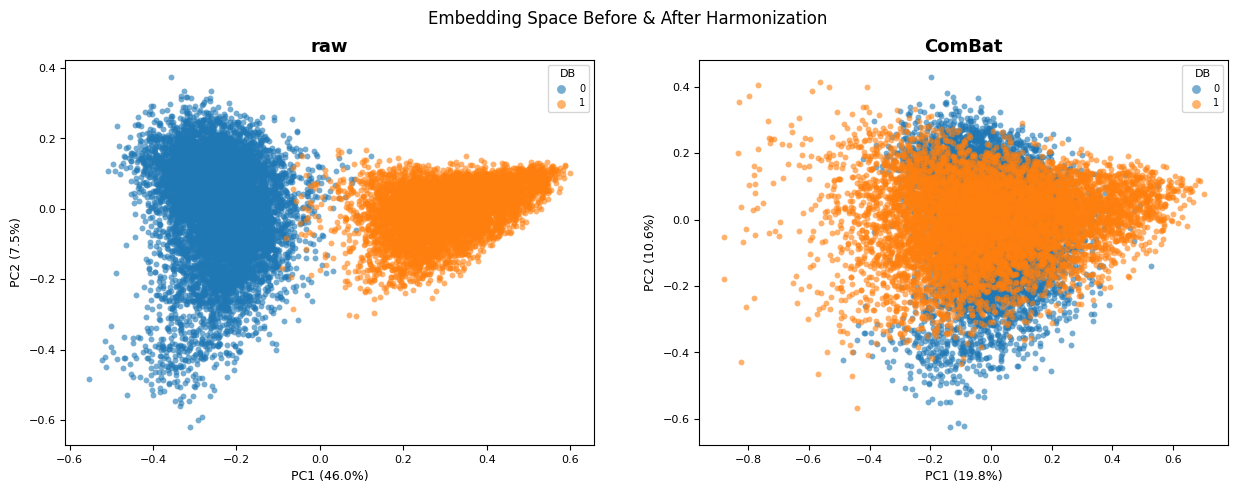

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Embedding Space Before & After Harmonization")

for col, (name, emb) in enumerate(embeddings.items()):
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(emb)
    var1, var2 = pca.explained_variance_ratio_ * 100

    ax = axes[col]
    unique_dbs = np.unique(db_labels)
    for db in unique_dbs:
        mask = db_labels == db
        ax.scatter(pcs[mask, 0], pcs[mask, 1], label=str(db), alpha=0.6, s=18, linewidths=0)
    ax.set_title(f"{name}", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"PC1 ({var1:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var2:.1f}%)", fontsize=9)
    ax.legend(fontsize=7, markerscale=1.5, title="DB", title_fontsize=8)
    ax.tick_params(labelsize=8)

In [9]:
df_combine["embed"] = list(combat_emb)

In [10]:
summary, model_results = run_embedding_classification(
    df_combine,
    train_db=0,
    test_dbs=[1],
    label_col="disease_status",
)
summary

Training classifiers:  50%|█████     | 1/2 [00:07<00:07,  7.19s/it]

Training classifiers: 100%|██████████| 2/2 [00:38<00:00, 19.01s/it]


{'mean_auroc_all_models': 0.67407630756599,
 'std_auroc_all_models': 0.0173373219829841,
 'mean_auroc_db1_all_models': 0.5152921988052525,
 'std_auroc_db1_all_models': 0.0029873595478046022}

## Outlier

In [11]:
raw_emb = np.stack(df_combine['embed'].values)
db_labels = df_combine['db'].values
disease_labels = df_combine['disease_status'].values

In [12]:
contamination = 0.05
pca = PCA(n_components=min(50, raw_emb.shape[1]), random_state=42)
emb_pca = pca.fit_transform(raw_emb)

# ─────────────────────────────────────────────
# METHOD A: Isolation Forest
# ─────────────────────────────────────────────
clf = IsolationForest(
    n_estimators=200,
    contamination=contamination, # Expected fraction of outliers 5%
    random_state=42,
    n_jobs=-1,
)
clf.fit_predict(emb_pca)        # 1 = inlier, -1 = outlier
if_scores = clf.score_samples(emb_pca)      # lower = more anomalous
if_scores = -if_scores  # IF scores are negative; negate so high = bad
if_scores = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min() + 1e-8)

# ─────────────────────────────────────────────
# METHOD B: Per-Class Centroid Distance
# ─────────────────────────────────────────────
threshold_sigma = 2.5 # threshold_sigma  : SD multiplier for outlier boundary
distances = np.zeros(len(raw_emb))
unique_classes = np.unique(db_labels)

for cls in unique_classes:
    mask = db_labels == cls
    subset = emb_pca[mask]
    centroid = subset.mean(axis=0)
    
    # Euclidean distance from centroid
    dists = np.linalg.norm(subset - centroid, axis=1)
    
    # Normalize by median (robust to outliers in the distance distribution)
    median_dist = np.median(dists)
    mad = np.median(np.abs(dists - median_dist)) + 1e-8  # Median Absolute Deviation
    normalized = (dists - median_dist) / mad
    distances[mask] = normalized # sigma

cd_norm = np.clip(distances, 0, None)  # remove negative (inlier side)
cd_norm = (cd_norm - cd_norm.min()) / (cd_norm.max() - cd_norm.min() + 1e-8)

# Ensemble
ensemble_scores = 0.55 * if_scores + 0.45 * cd_norm
threshold = np.percentile(ensemble_scores, 100 * (1 - contamination))
outlier_labels = np.where(ensemble_scores >= threshold, -1, 1)

outlier_mask = outlier_labels == -1
inlier_mask = outlier_labels == 1
n_outliers = outlier_mask.sum()
print(f"  outliers: {n_outliers} ({outlier_mask.mean()*100:.1f}%)")

  outliers: 836 (5.0%)


Text(0, 0.5, 'PC2 (10.6%)')

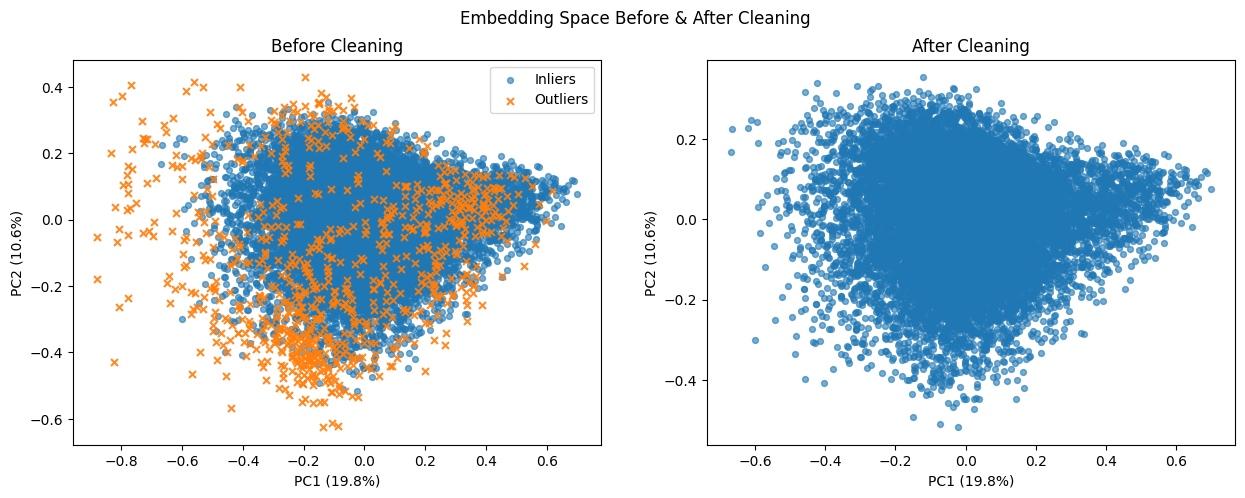

In [13]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(raw_emb)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle("Embedding Space Before & After Cleaning")

# BEFORE
ax = axes[0]
ax.scatter(pcs[inlier_mask,0], pcs[inlier_mask,1], s=18, alpha=0.6, label="Inliers")
ax.scatter(pcs[~inlier_mask,0], pcs[~inlier_mask,1], s=25, alpha=0.9, marker="x", label="Outliers")

ax.set_title("Before Cleaning")
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.legend()

# AFTER
ax = axes[1]
ax.scatter(pcs[inlier_mask,0], pcs[inlier_mask,1], s=18, alpha=0.6)

ax.set_title("After Cleaning")
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")

In [14]:
df_combine = df_combine[~outlier_mask].reset_index(drop=True)

In [15]:
summary, model_results = run_embedding_classification(
    df_combine,
    train_db=0,
    test_dbs=[1],
    label_col="disease_status",
)
summary

Training classifiers:   0%|          | 0/2 [00:00<?, ?it/s]

Training classifiers: 100%|██████████| 2/2 [00:33<00:00, 16.97s/it]


{'mean_auroc_all_models': 0.6768408566892735,
 'std_auroc_all_models': 0.01479977648052977,
 'mean_auroc_db1_all_models': 0.5126040396767049,
 'std_auroc_db1_all_models': 0.002268530258896728}

## Intra Classs

In [21]:
def _auto_pca_components(
    embeddings: np.ndarray,
    variance_threshold: float = 0.95,
    random_state: int = 42,
) -> int:
    """
    Find minimum n_components that explains `variance_threshold` of total variance.
    Fits PCA with full components, reads cumulative explained variance ratio.

    Parameters
    ----------
    variance_threshold : float in (0, 1]
        Target cumulative explained variance. Default 0.95 (95%).
        Use 0.99 for higher fidelity, 0.90 for more compression.

    Returns
    -------
    n_components : int — minimum dims to reach the threshold
    explained    : float — actual variance explained at that n
    """
    max_comp = min(embeddings.shape[0] - 1, embeddings.shape[1])
    pca_full = PCA(n_components=max_comp, random_state=random_state)
    pca_full.fit(embeddings)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp = int(np.searchsorted(cumvar, variance_threshold) + 1)
    n_comp = min(n_comp, max_comp)
    explained = cumvar[n_comp - 1]
    print(f"      Auto PCA: {n_comp} components explain {explained*100:.1f}% variance "
          f"(threshold={variance_threshold*100:.0f}%)")
    return n_comp, explained

def _posterior(log_p_tb, log_p_nontb):
    """Numerically stable Bayesian posterior P(TB|x) from log-likelihoods."""
    log_max = np.maximum(log_p_tb, log_p_nontb)
    num = np.exp(log_p_tb - log_max)
    den = num + np.exp(log_p_nontb - log_max) + 1e-8
    return (num / den).astype(np.float32)

def knn_tb_score( emb_reduced, tb_emb, nontb_emb, k_knn=15, metric="euclidean"):
    if k_knn is None:
        k_tb, _ = find_optimal_k(tb_emb, random_state=42)
        k_nontb, _ = find_optimal_k(nontb_emb, random_state=42)
    else:
        k_tb = min(k_knn, len(tb_emb))
        k_nontb = min(k_knn, len(nontb_emb))

    kw_nn = {"metric": metric}
    if metric == "mahalanobis":
        cov = np.cov(emb_reduced.T)
        VI = np.linalg.inv(cov + np.eye(cov.shape[0]) * 1e-6)
        kw_nn["metric_params"] = {"VI": VI}

    # Fit separate NN indices for each class
    nn_tb = NearestNeighbors(n_neighbors=k_tb, n_jobs=-1, **kw_nn).fit(tb_emb)
    nn_nontb = NearestNeighbors(n_neighbors=k_nontb, n_jobs=-1, **kw_nn).fit(nontb_emb)

    # Query distances for all samples
    d_tb, _ = nn_tb.kneighbors(emb_reduced)
    d_nontb, _ = nn_nontb.kneighbors(emb_reduced)

    mean_d_tb = d_tb.mean(axis=1)
    mean_d_nontb = d_nontb.mean(axis=1)

    # Total Distance Score, [nonTB] ----------- x --- [TB] -> 0 - 1, tell how far from non tb
    scores_raw = mean_d_nontb / (mean_d_tb + mean_d_nontb + 1e-8) # Relative proximity score: high = closer to TB
    return _minmax_normalize(scores_raw)

In [17]:
raw_emb = np.stack(df_combine['embed'].values)
db_labels = df_combine['db'].values
disease_labels = df_combine['disease_status'].values

tb_mask = disease_labels == 1

In [52]:
all_scores = {}
variance_threshold = 0.95
method_reduction = "pca" # "umap" "pca"
n_components = 30 #20–50
#n_components, _ = _auto_pca_components(raw_emb, variance_threshold, 42)
N, D = raw_emb.shape

reducer = PCA(n_components=n_components, random_state=42)
#reducer = umap.UMAP(n_components=n_components, n_neighbors=min(15, N // 10), min_dist=0.1, metric="euclidean", n_jobs=-1, random_state=42)
emb_reduced = reducer.fit_transform(raw_emb)

tb_emb   = emb_reduced[tb_mask]
nontb_emb = emb_reduced[~tb_mask]

In [53]:
"""
One-Class Kernel Density Estimation on Non-TB samples.

Intuition
---------
Model the "normal cough" (Non-TB) distribution using KDE.
A sample that falls in a LOW-density region of Non-TB space
is acoustically unusual → likely TB.

Score = 1 - P(x | Non-TB)  →  high score = far from Non-TB = likely TB

This is purely unsupervised with respect to TB labels:
the TB label is only used to define what "normal" means (Non-TB).
No linearity assumption. Works on the full non-linear manifold
via the kernel.

Parameters
----------
pca_components : dims to reduce to before KDE (KDE suffers in very high dims)
"""

# Bandwidth selection via Scott's rule
bandwidth = nontb_emb.shape[0] ** (-1.0 / (nontb_emb.shape[1] + 4))
bandwidth = max(bandwidth, 0.1)

kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
kde.fit(nontb_emb)

log_density = kde.score_samples(emb_reduced)  # (N,) — higher = more like Non-TB
scores = -log_density  # Invert: high score = anomalous w.r.t. Non-TB = likely TB
all_scores["kde"] = _sigmoid_normalize(scores)

In [ ]:
"""
k-Nearest Neighbor distance-based acoustic TB likelihood.

Intuition
---------
For each sample, compute:
    d_TB     = mean distance to its k nearest TB neighbors
    d_NonTB  = mean distance to its k nearest Non-TB neighbors

Score = d_NonTB / (d_TB + d_NonTB)
    → high score = closer to TB neighborhood = likely TB
    → low score  = closer to Non-TB neighborhood = likely Non-TB

Makes NO distributional assumptions. Captures non-linear, multi-modal
cluster structure. Each sample is judged by its local neighborhood,
not a global decision boundary.

Parameters
----------
k : number of neighbors (15–25 works well for large datasets)
"""
k_knn = 15
all_scores["knn_euc"] = knn_tb_score(emb_reduced, tb_emb, nontb_emb, k_knn=None, metric="euclidean")
all_scores["knn_cos"] = knn_tb_score(emb_reduced, tb_emb, nontb_emb, k_knn=None, metric="cosine")
all_scores["knn_maha"] = knn_tb_score(emb_reduced, tb_emb, nontb_emb, k_knn=None, metric="mahalanobis")

In [ ]:
"""
Nearest Centroid / Medoid Score.

Instead of k neighbors, uses a single reference point per class:
    - Centroid: mean of all class embeddings (fast, sensitive to outliers)
    - Medoid:   actual sample with minimum mean distance to all class members
                (robust to outliers, more representative)

score = d(x, centroid_NonTB) / (d(x, centroid_TB) + d(x, centroid_NonTB))

Simpler and more stable than kNN in very high dimensions.
Medoid variant is preferred when class distributions are skewed.
"""

def get_ref(class_emb, use_medoid):
    if not use_medoid:
        return class_emb.mean(axis=0)
    # Medoid: sample with minimum mean pairwise distance to all others
    from sklearn.metrics import pairwise_distances
    D = pairwise_distances(class_emb, metric="euclidean")
    return class_emb[D.mean(axis=1).argmin()]

use_medoid = True
ref_tb    = get_ref(tb_emb,    use_medoid)
ref_nontb = get_ref(nontb_emb, use_medoid)

d_tb    = np.linalg.norm(emb_reduced - ref_tb,    axis=1)
d_nontb = np.linalg.norm(emb_reduced - ref_nontb, axis=1)

scores = d_nontb / (d_tb + d_nontb + 1e-8)
all_scores["centroid"] = _minmax_normalize(scores)

In [56]:
"""
Gaussian Mixture Model posterior: P(TB | x).

Intuition
---------
Fit a separate GMM on TB samples and on Non-TB samples.
Each GMM models the multi-modal, non-linear structure of its class.
Score = P(x | GMM_TB) / (P(x | GMM_TB) + P(x | GMM_NonTB))
        = Bayesian posterior P(TB | x) assuming equal class priors.

Unlike LDA, this:
    - Handles multi-modal distributions (multiple acoustic TB subtypes)
    - Captures non-linear cluster shapes via mixture of Gaussians
    - Gives a proper probabilistic score with Bayesian interpretation

n_components auto-selected via BIC if not provided.

Parameters
----------
n_components_tb    : GMM components for TB class (None = auto via BIC)
n_components_nontb : GMM components for Non-TB class (None = auto via BIC)
"""

gmm_tb = best_gmm(tb_emb, max_k=32, random_state=42)
gmm_nontb = best_gmm(nontb_emb, max_k=32, random_state=42)

# Log-likelihoods
log_p_tb    = gmm_tb.score_samples(emb_reduced)    # (N,) log P(x | TB)
log_p_nontb = gmm_nontb.score_samples(emb_reduced) # (N,) log P(x | Non-TB)

# # Stable log-sum-exp for posterior
# # P(TB|x) = exp(log_p_tb) / (exp(log_p_tb) + exp(log_p_nontb)) , The probability that the sample has TB given the observed data x
# log_max = np.maximum(log_p_tb, log_p_nontb)
# posterior_tb = np.exp(log_p_tb - log_max) / (
#     np.exp(log_p_tb - log_max) + np.exp(log_p_nontb - log_max) + 1e-8
# )
# posterior_tb = posterior_tb.astype(np.float32)
posterior_tb = _posterior(log_p_tb, log_p_nontb)
all_scores["gmm"] = posterior_tb

############### One Class GMM ################
gmm_tb = best_gmm(tb_emb, max_k=32, random_state=42)
log_p_tb    = gmm_tb.score_samples(emb_reduced)    # (N,) log P(x | TB)
all_scores["ocgmm"] = _minmax_normalize(log_p_tb)

    GMM components selected (BIC): 23
    GMM components selected (BIC): 32
    GMM components selected (BIC): 23


In [57]:
"""
One-Class SVM fitted on Non-TB only.

Learns a hypersphere around the Non-TB distribution.
score = -decision_function → high = outside Non-TB boundary = likely TB.

No Gaussian assumption. RBF kernel handles non-linearity.
nu = upper bound on fraction of Non-TB outliers (tune 0.05–0.2).
"""

ocsvm = OneClassSVM(kernel="rbf", nu=0.1, gamma="scale")
ocsvm.fit(nontb_emb)
all_scores["ocsvm_nontb"] = _minmax_normalize(-ocsvm.decision_function(emb_reduced))

In [58]:
"""
One-Class SVM fitted on TB samples only.

Symmetric to score_ocsvm_nontb: models the TB distribution instead.
score = decision_function (positive = inside TB boundary = likely TB).

High score → sample lies inside the TB hypersphere → acoustically TB-like.
"""

ocsvm = OneClassSVM(kernel="rbf", nu=0.1, gamma="scale")
ocsvm.fit(tb_emb)
all_scores["ocsvm_tb"] = _minmax_normalize(-ocsvm.decision_function(emb_reduced))

In [59]:
"""
LOF fitted on Non-TB only — anomaly w.r.t. Non-TB distribution.

High score → sample is isolated relative to its Non-TB neighborhood
            → likely not a typical Non-TB cough → possibly TB.
"""
n_neighbors = 20
lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True, n_jobs=-1)
lof.fit(nontb_emb)
all_scores["lof_nontb"] = _minmax_normalize(-lof.score_samples(emb_reduced))

In [60]:
"""
LOF fitted on TB samples only — anomaly w.r.t. TB distribution.

Conceptually: if TB samples cluster tightly and a test sample is
far from any TB neighbor, LOF marks it as non-TB-like.

High anomaly score under TB model → isolated from TB cluster → likely Non-TB.
We invert so: high final score → fits well inside TB density → likely TB.
"""
n_neighbors = 20
lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True, n_jobs=-1)
lof.fit(tb_emb)
# score_samples: less negative = more inlier = fits TB well = TB-like
all_scores["lof_tb"] = _minmax_normalize(lof.score_samples(emb_reduced))

In [61]:
"""
Nearest Shrunken Centroid (NSC) Score.

Adapted from the Prediction Analysis of Microarrays (PAM) method,
originally designed for gene expression — directly applicable to
high-dimensional embeddings.

How it works:
    1. Compute per-class centroid and overall centroid
    2. Compute per-feature within-class standard deviation (pooled)
    3. Compute t-statistic: d_jk = (centroid_k_j - overall_j) / (s_j + s0)
        where s0 is a small regularization constant preventing division by near-zero
    4. Shrink d_jk toward zero by threshold Δ (soft thresholding)
        → features where the class differs little from overall are zeroed out
        → implicit feature selection: only discriminative features remain
    5. Score = distance to shrunken Non-TB centroid minus distance to shrunken TB centroid

Advantages over plain nearest centroid:
    - Automatic feature selection (irrelevant embedding dims zeroed)
    - Better generalization in high dimensions
    - Interpretable: non-zero features are the discriminative acoustic dimensions

shrinkage_threshold : Δ, higher = more aggressive feature selection.
                        0 = no shrinkage (plain centroid). Tune 0.1–2.0.
"""
shrinkage_threshold = 0.5
overall   = emb_reduced.mean(axis=0)

# Pooled within-class std per feature
s_j = np.sqrt(((tb_emb - tb_emb.mean(axis=0))**2).sum(axis=0) +
    ((nontb_emb - nontb_emb.mean(axis=0))**2).sum(axis=0)) / (len(emb) - 2)
s0 = np.median(s_j)  # regularization: median pooled std

def shrink_centroid(class_emb, n_k):
    m_k = class_emb.mean(axis=0)
    # t-statistic for this class
    d_k = (m_k - overall) / (s_j + s0) * np.sqrt(1.0/n_k + 1.0/len(emb))
    # Soft threshold: shrink toward zero
    d_k_shrunk = np.sign(d_k) * np.maximum(np.abs(d_k) - shrinkage_threshold, 0)
    # Shrunken centroid = overall + shrunk displacement
    return overall + d_k_shrunk * (s_j + s0) / np.sqrt(1.0/n_k + 1.0/len(emb))

c_tb    = shrink_centroid(tb_emb,    len(tb_emb))
c_nontb = shrink_centroid(nontb_emb, len(nontb_emb))

d_tb    = np.linalg.norm(emb_reduced - c_tb,    axis=1)
d_nontb = np.linalg.norm(emb_reduced - c_nontb, axis=1)

scores = d_nontb / (d_tb + d_nontb + 1e-8)
all_scores["shrunken_centroid"] = _minmax_normalize(scores)

In [62]:
# Per-method breakdown
for m, s in all_scores.items():
    if m == "ensemble": continue
    print(f"  [{m.upper()}] TB: {s[tb_mask].mean():.3f} ± {s[tb_mask].std():.3f} | " f"Non-TB: {s[~tb_mask].mean():.3f} ± {s[~tb_mask].std():.3f}")

  [KDE] TB: 0.499 ± 0.183 | Non-TB: 0.481 ± 0.196
  [KNN_EUC] TB: 0.774 ± 0.062 | Non-TB: 0.229 ± 0.049
  [KNN_COS] TB: 0.738 ± 0.093 | Non-TB: 0.237 ± 0.070
  [KNN_MAHA] TB: 0.767 ± 0.060 | Non-TB: 0.218 ± 0.048
  [CENTROID] TB: 0.497 ± 0.018 | Non-TB: 0.498 ± 0.018
  [GMM] TB: 0.615 ± 0.335 | Non-TB: 0.310 ± 0.298
  [OCGMM] TB: 0.511 ± 0.104 | Non-TB: 0.507 ± 0.123
  [OCSVM_NONTB] TB: 0.488 ± 0.163 | Non-TB: 0.458 ± 0.169
  [OCSVM_TB] TB: 0.438 ± 0.144 | Non-TB: 0.431 ± 0.161
  [LOF_NONTB] TB: 0.161 ± 0.105 | Non-TB: 0.124 ± 0.082
  [LOF_TB] TB: 0.874 ± 0.082 | Non-TB: 0.837 ± 0.106
  [SHRUNKEN_CENTROID] TB: 0.457 ± 0.076 | Non-TB: 0.448 ± 0.085


In [37]:
list(all_scores.keys())

['kde',
 'knn_euc',
 'knn_cos',
 'knn_maha',
 'centroid',
 'gmm',
 'ocgmm',
 'ocsvm_nontb',
 'ocsvm_tb',
 'kde_ratio',
 'lof_nontb',
 'lof_tb',
 'shrunken_centroid']

In [63]:
# Simple average — each method captures different aspects
scores_ensembles = np.mean([all_scores["knn_cos"], all_scores["gmm"]], axis=0) #np.mean(list(all_scores.values()), axis=0)
all_scores["ensemble"] = scores_ensembles
acoustic_scores = scores_ensembles # , all_scores["kde"]

print(f"  Ensemble TB mean score:     {acoustic_scores[tb_mask].mean():.3f} ± {acoustic_scores[tb_mask].std():.3f}")
print(f"  Ensemble Non-TB mean score: {acoustic_scores[~tb_mask].mean():.3f} ± {acoustic_scores[~tb_mask].std():.3f}")

  Ensemble TB mean score:     0.676 ± 0.191
  Ensemble Non-TB mean score: 0.273 ± 0.160


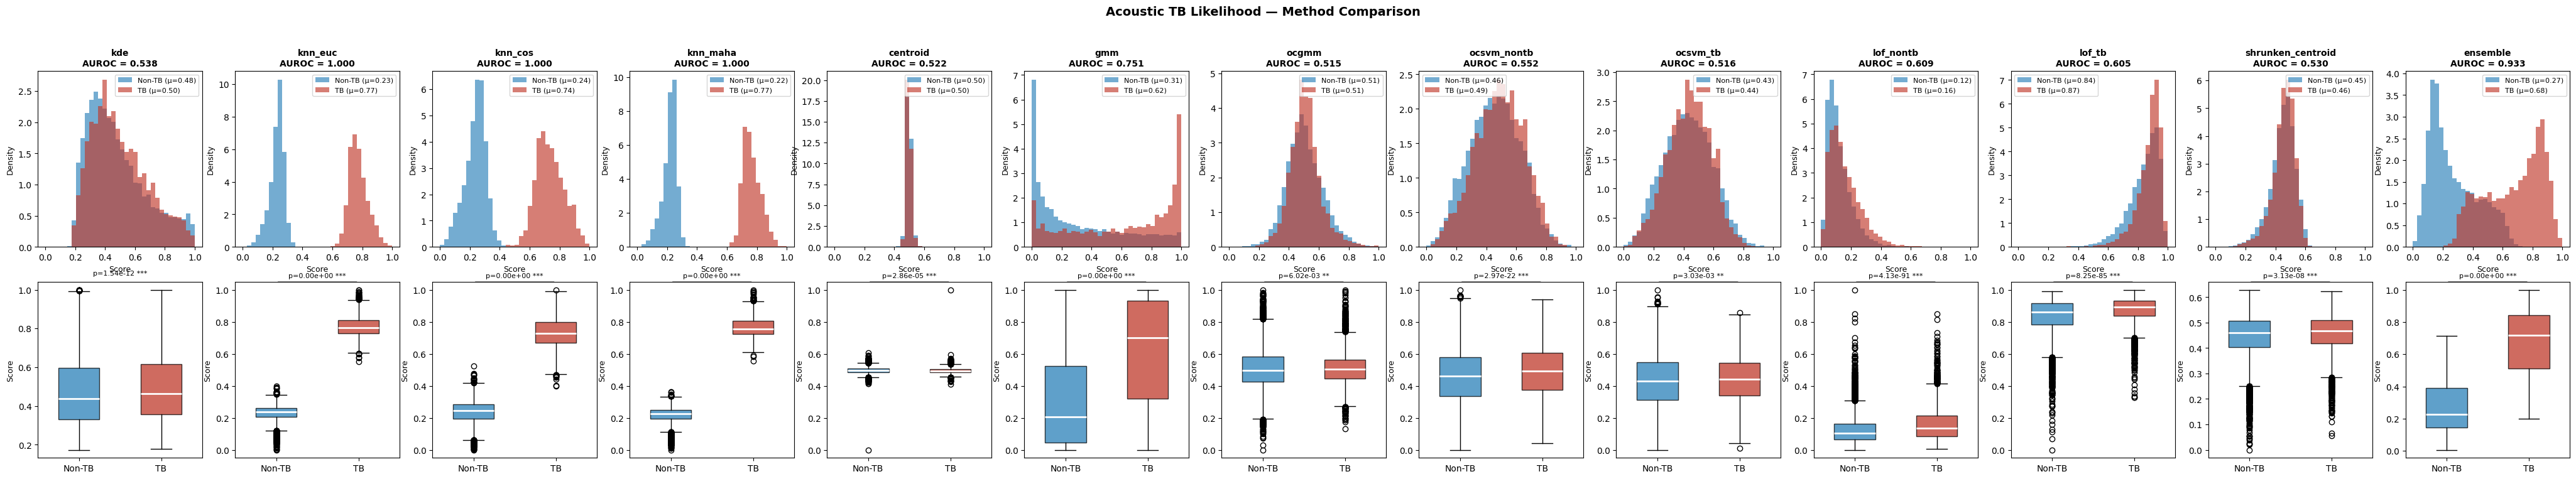

In [64]:
from scipy.stats import mannwhitneyu

methods = list(all_scores.keys()) #[m for m in ["kde", "knn", "gmm", "ocsvm", "lof", "ensemble"] if m in all_scores]
n = len(methods)

fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle("Acoustic TB Likelihood — Method Comparison", fontsize=14, fontweight="bold", y=1.01)

method_labels = {"kde": "One-Class KDE\n(Non-TB density anomaly)",
                     "knn": "k-NN Distance\n(local neighborhood)",
                     "gmm": "GMM Posterior\nP(TB|x)",
                     "ensemble": "Ensemble\n(average of 3)"}
# method_labels.get(method, method)
colors = {"TB": "#C0392B", "Non-TB": "#2980B9"}

for col, method in enumerate(methods):
    scores = all_scores[method]
    tb_scores    = scores[tb_mask]
    nontb_scores = scores[~tb_mask]

    # Row 0: distribution
    ax = axes[0, col]
    bins = np.linspace(0, 1, 35)
    ax.hist(nontb_scores, bins=bins, color=colors["Non-TB"], alpha=0.65,
            label=f"Non-TB (μ={nontb_scores.mean():.2f})", density=True)
    ax.hist(tb_scores, bins=bins, color=colors["TB"], alpha=0.65,
            label=f"TB (μ={tb_scores.mean():.2f})", density=True)

    # AUC-like separation: how well does this score separate classes?
    from sklearn.metrics import roc_auc_score
    try:
        auc = roc_auc_score(tb_mask.astype(int), scores)
        auc = max(auc, 1 - auc)  # always report > 0.5
    except Exception:
        auc = float("nan")

    ax.set_title(f"{method}\nAUROC = {auc:.3f}",
                    fontsize=10, fontweight="bold")
    ax.set_xlabel("Score", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)

    # Row 1: box plot per class
    ax = axes[1, col]
    data_plot = [nontb_scores, tb_scores]
    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], [colors["Non-TB"], colors["TB"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Non-TB", "TB"], fontsize=10)
    ax.set_ylabel("Score", fontsize=9)

    # Statistical test
    stat, pval = mannwhitneyu(tb_scores, nontb_scores, alternative="two-sided")
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
    ymax = max(tb_scores.max(), nontb_scores.max())
    ax.annotate("", xy=(2, ymax * 1.05), xytext=(1, ymax * 1.05),
                arrowprops=dict(arrowstyle="-", color="black"))
    ax.text(1.5, ymax * 1.07, f"p={pval:.2e} {sig}",
            ha="center", va="bottom", fontsize=8)

In [69]:
df_tb = df_combine[tb_mask].copy().reset_index(drop=True)
tb_acoustic_scores = acoustic_scores[tb_mask]
ntb_acoustic_scores = acoustic_scores[~tb_mask]

df_tb["acoustic_tb_score"] = tb_acoustic_scores

threshold = np.median(tb_acoustic_scores) # Try Median
#threshold = np.percentile(tb_acoustic_scores, 85)
#threshold = np.percentile(ntb_acoustic_scores, 99)# + 0.05
df_tb["tb_acoustic_subtype"] = np.where(
    tb_acoustic_scores >= threshold,
    "Acoustic-TB",
    "Label-only-TB"
)

df_combine["acoustic_tb_score"] = acoustic_scores
subtype_col = np.array([0] * len(df_combine), dtype=object)
tb_idx_positions = np.where(tb_mask)[0]
for i, pos in enumerate(tb_idx_positions):
    subtype_col[pos] = 1 if df_tb["tb_acoustic_subtype"].iloc[i] == "Acoustic-TB" else 2
df_combine["disease_status_rev"] = subtype_col

n_acoustic = (df_tb["tb_acoustic_subtype"] == "Acoustic-TB").sum()
n_labelonly = (df_tb["tb_acoustic_subtype"] == "Label-only-TB").sum()
print(f"  Acoustic-TB:    {n_acoustic} ({n_acoustic/len(df_tb)*100:.1f}%)")
print(f"  Label-only-TB:  {n_labelonly} ({n_labelonly/len(df_tb)*100:.1f}%)\n")

print(f"  Acoustic-TB:    {df_tb[df_tb["tb_acoustic_subtype"] == "Acoustic-TB"]['acoustic_tb_score'].mean()}")
print(f"  Label-only-TB:  {df_tb[df_tb["tb_acoustic_subtype"] == "Label-only-TB"]['acoustic_tb_score'].mean()}")

  Acoustic-TB:    1893 (50.0%)
  Label-only-TB:  1893 (50.0%)

  Acoustic-TB:    0.8399335487825216
  Label-only-TB:  0.5130266391102685


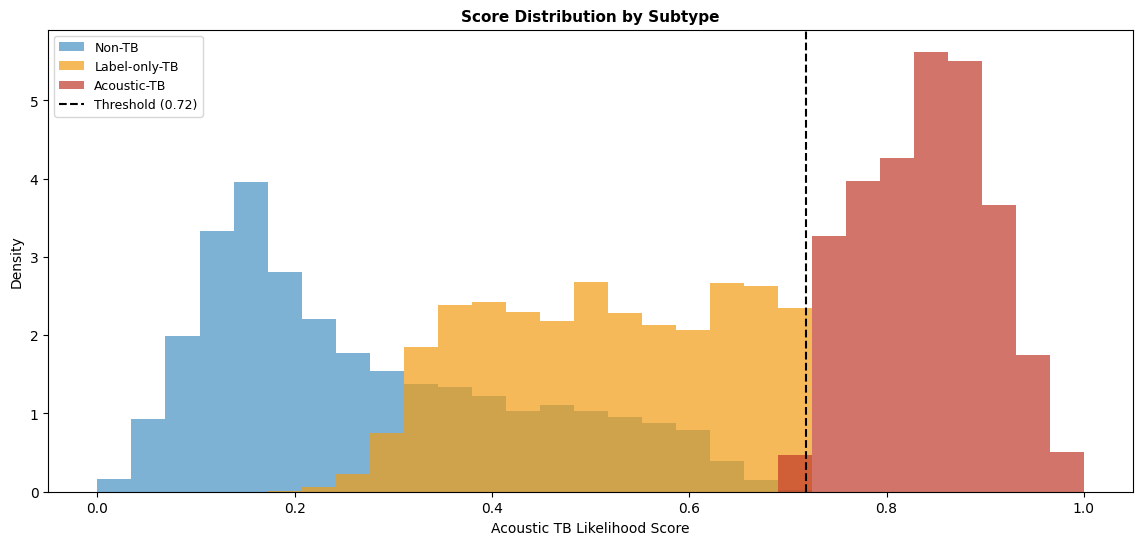

In [70]:
# Right: Acoustic TB Score distribution
fig, axes = plt.subplots(1, 1, figsize=(14, 6))
ax = axes

tb_idx = np.where(tb_mask)[0]
nontb_idx = np.where(~tb_mask)[0]

nontb_scores = acoustic_scores[~tb_mask]
tb_acoustic_scores = acoustic_scores[tb_mask]

# Split TB by subtype
subtypes = df_tb["tb_acoustic_subtype"].values
acoustic_tb_scores = acoustic_scores[tb_idx[subtypes == "Acoustic-TB"]]
labelonly_tb_scores = acoustic_scores[tb_idx[subtypes == "Label-only-TB"]]

bins = np.linspace(0, 1, 30)
ax.hist(nontb_scores, bins=bins, color="#2980B9", alpha=0.6, label="Non-TB", density=True)
ax.hist(labelonly_tb_scores, bins=bins, color="#F39C12", alpha=0.7, label="Label-only-TB", density=True)
ax.hist(acoustic_tb_scores, bins=bins, color="#C0392B", alpha=0.7, label="Acoustic-TB", density=True)

ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold:.2f})")
ax.set_xlabel("Acoustic TB Likelihood Score", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title("Score Distribution by Subtype", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)

In [71]:
summary, model_results = run_embedding_classification(
    df_combine[df_combine["disease_status_rev"] != 2].copy().reset_index(drop=True),
    train_db=0,
    test_dbs=[1],
    label_col="disease_status_rev",
)
summary

Training classifiers:   0%|          | 0/2 [00:00<?, ?it/s]

Training classifiers: 100%|██████████| 2/2 [00:24<00:00, 12.03s/it]


{'mean_auroc_all_models': 0.7532532796948874,
 'std_auroc_all_models': 0.010516129660376738,
 'mean_auroc_db1_all_models': 0.5532029930878007,
 'std_auroc_db1_all_models': 0.0053526672646685425}

In [72]:
summary, model_results = run_embedding_classification(
    df_combine[df_combine["disease_status_rev"] != 2].copy().reset_index(drop=True),
    train_db=1,
    test_dbs=[0],
    label_col="disease_status_rev",
)
summary

Training classifiers:   0%|          | 0/2 [00:00<?, ?it/s]

Training classifiers: 100%|██████████| 2/2 [00:13<00:00,  6.66s/it]


{'mean_auroc_all_models': 0.7095708206637397,
 'std_auroc_all_models': 0.007168042488814086,
 'mean_auroc_db0_all_models': 0.5117206009794703,
 'std_auroc_db0_all_models': 0.004535562598900422}

In [73]:
summary, model_results = run_embedding_classification(
    df_combine[df_combine["disease_status_rev"] != 2].copy().reset_index(drop=True),
    train_db=[0, 1],
    label_col="disease_status_rev",
)
summary

Training classifiers:   0%|          | 0/2 [00:00<?, ?it/s]

Training classifiers: 100%|██████████| 2/2 [00:41<00:00, 20.99s/it]


{'mean_auroc_all_models': 0.7752129490758616,
 'std_auroc_all_models': 0.03464623683688883}

## Evaluate

In [ ]:
COLORS = ["#C0392B", "#2980B9", "#27AE60", "#8E44AD"]

def plot_cross_dataset_roc(cross_results: dict, save_path: str = None):
    """
    ROC curves for all cross-dataset directions, one panel per direction.
    All classifiers shown per panel.
    """
    directions = list(cross_results.keys())
    n = len(directions)
    if n == 0:
        return

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle("Cross-Dataset Generalization — ROC Curves",
                 fontsize=14, fontweight="bold")

    for ax, direction in zip(axes, directions):
        clf_results = cross_results[direction]
        for (clf_name, res), color in zip(clf_results.items(), COLORS):
            ax.plot(res["fpr"], res["tpr"], color=color, linewidth=2,
                    label=f"{clf_name} (AUROC={res['auroc']:.3f})")

        ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
        ax.set_title(f"Train → Test:\n{direction}", fontsize=11, fontweight="bold")
        ax.set_xlabel("False Positive Rate", fontsize=10)
        ax.set_ylabel("True Positive Rate", fontsize=10)
        ax.legend(fontsize=8, loc="lower right")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
        _style_ax(ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.close()